## Decision Tree for Binary Classfication
In a decision tree, we decide if a node will be split or not by looking at the **information gain** that split would give us. 

Where 

$$\text{Information Gain} = H(p_1^\text{node})- \left(w^{\text{left}}H\left(p_1^\text{left}\right) + w^{\text{right}}H\left(p_1^\text{right}\right)\right),$$

and $H$ is the entropy, defined as

$$H(p_1) = -p_1 \text{log}_2(p_1) - (1- p_1) \text{log}_2(1- p_1)$$

In [1]:
import pandas as pd
import numpy as np

In [2]:
X_train = np.array([[1, 1, 1],
[0, 0, 1],
 [0, 1, 0],
 [1, 0, 1],
 [1, 1, 1],
 [1, 1, 0],
 [0, 0, 0],
 [1, 1, 0],
 [0, 1, 0],
 [0, 1, 0]])

y_train = np.array([1, 1, 0, 0, 1, 1, 0, 1, 0, 0])


- Ear Shape: Pointy = 1, Floppy = 0
- Face Shape: Round = 1, Not Round = 0
- Whiskers: Present = 1, Absent = 0

Therefore, we have two sets:

- `X_train`: for each example, contains 3 features:
            - Ear Shape (1 if pointy, 0 otherwise)
            - Face Shape (1 if round, 0 otherwise)
            - Whiskers (1 if present, 0 otherwise)
            
- `y_train`: whether the animal is a cat
            - 1 if the animal is a cat
            - 0 otherwise


  ---

In [3]:
#For instance, the first example
X_train[0]

array([1, 1, 1])

This means that the first example has a pointy ear shape, round face shape and it has whiskers.

In [4]:
def compute_entropy(y):

    p = 0
    
    if len(y) == 0:
        return 0
    p = sum(y)/len(y)
    if p == 0 or p == 1:
        return 0
    else:
        return -p*np.log2(p) - (1-p)*np.log2(1-p)
     

print(compute_entropy(y_train))

1.0


In [5]:
def split_dataset(X, node_indices, feature_idx):
    """Given a dataset and a feature_idx, return two lists for the two split nodes, the left node has the animals that have 
    that feature = 1 and the right node those that have the feature = 0 
    feature_idx = 0 => ear shape
    feature_idx = 1 => face shape
    feature_idx = 2 => whiskers
    """

    left_indices = []
    right_indices = []
    

    for i in node_indices:
        if X[i][feature_idx] == 1:
            left_indices.append(i)
        else:
            right_indices.append(i)


    return left_indices,right_indices

In [6]:
split_dataset(X_train,[0,1,2,3,4,5,6,7,8,9],0)

([0, 3, 4, 5, 7], [1, 2, 6, 8, 9])

In [7]:
def compute_information_gain(X,y,node_indices,feature):
    """
    This function takes the splitted dataset, the indices we chose to split and returns the weighted entropy.
    """

    left_indices,right_indices = split_dataset(X, node_indices, feature)

    X_node, y_node = X[node_indices], y[node_indices]
    X_left, y_left = X[left_indices], y[left_indices]
    X_right, y_right = X[right_indices], y[right_indices]
    

    information_gain=0


   
    node_entropy = compute_entropy(y_node)
    left_entropy = compute_entropy(y_left)
    right_entropy = compute_entropy(y_right)
    w_left = len(X_left) / len(X_node)
    w_right = len(X_right) / len(X_node)

   

    weighted_entropy = w_left * left_entropy + w_right * right_entropy


    return node_entropy - weighted_entropy


    

In [8]:
compute_information_gain(X_train, y_train, [0,1,2,3,4,5,6,7,8,9], 0)

np.float64(0.2780719051126377)

In [9]:
def get_best_split(X, y, node_indices):   
    num_features = X.shape[1]
    
    best_feature = -1

    max_info_gain = 0
    for feature in range(num_features):
        info_gain = compute_information_gain(X, y, node_indices, feature)
        if info_gain > max_info_gain:
            max_info_gain = info_gain
            best_feature = feature
        
   
    return best_feature

In [10]:
def build_tree_recursive(X, y, node_indices, branch_name, max_depth, current_depth, tree):

    # Stopping condition
    if current_depth == max_depth:
        print("    " * current_depth + f"{branch_name} Leaf -> {node_indices}")
        return

    # Find the best feature
    best_feature = get_best_split(X, y, node_indices)

    # Print current node
    print("    " * current_depth +
          f"{branch_name} Node (Depth {current_depth}) -> Split on Feature {best_feature}")

    # Split the dataset
    left_indices, right_indices = split_dataset(X, node_indices, best_feature)

    # Store the split
    tree.append((left_indices, right_indices, best_feature))

    # Recursive calls
    build_tree_recursive(
        X, y, left_indices,
        "Left",
        max_depth,
        current_depth + 1,
        tree
    )

    build_tree_recursive(
        X, y, right_indices,
        "Right",
        max_depth,
        current_depth + 1,
        tree
    )

    return tree

In [11]:
tree = []
build_tree_recursive(X_train, y_train, [0,1,2,3,4,5,6,7,8,9], "Root", max_depth=2, current_depth=0, tree = tree)


Root Node (Depth 0) -> Split on Feature 0
    Left Node (Depth 1) -> Split on Feature 1
        Left Leaf -> [0, 4, 5, 7]
        Right Leaf -> [3]
    Right Node (Depth 1) -> Split on Feature 2
        Left Leaf -> [1]
        Right Leaf -> [2, 6, 8, 9]


[([0, 3, 4, 5, 7], [1, 2, 6, 8, 9], 0),
 ([0, 4, 5, 7], [3], 1),
 ([1], [2, 6, 8, 9], 2)]

---

## Decision Tree Visualization


In [12]:
from sklearn.tree import DecisionTreeClassifier

cls = DecisionTreeClassifier(
    criterion="gini",      # or "entropy", "log_loss"
    max_depth=3,
    random_state=42
)

cls.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [13]:
#install dtreeviz
!pip install dtreeviz

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from dtreeviz import model

In [15]:
features = ['Ear_Shape','Face_Shape','Whisters']

In [16]:
viz = model(cls,X_train,y_train,feature_names=features,class_names=['Cat','Not Cat'])


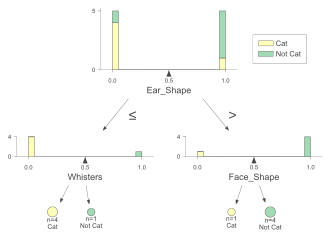

In [17]:
viz.view()

In [20]:
X=[0, 0, 0]
viz = model(cls,X_train,y_train,feature_names=features,class_names=['Cat','Not Cat'])


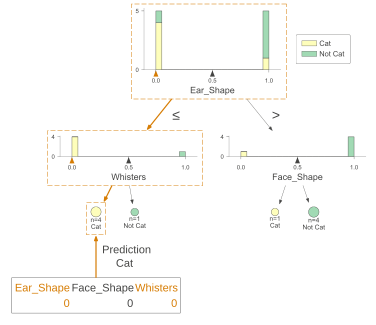

In [21]:
viz.view(x=X)

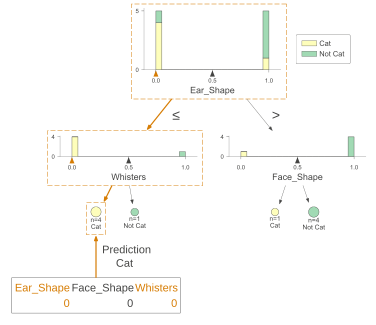

In [29]:
X=[0, 0, 0]
viz = model(cls,X_train,y_train,feature_names=features,class_names=['Cat','Not Cat'],)

viz.view(x=X)


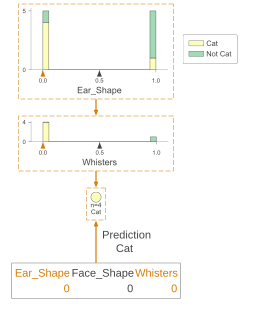

In [30]:
X=[0, 0, 0]
viz = model(cls,X_train,y_train,feature_names=features,class_names=['Cat','Not Cat'],)

viz.view(x=X,show_just_path=True)
